https://www.learnpytorch.io/

# Convolutional Neural Network

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Importing the libraries

In [ ]:
import pandas as pd
import numpy as np
import torch as torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import os

In [ ]:
torch.__version__

'2.10.0+cu128'

## Part 1 - Data Preprocessing

### Preprocessing the Training set

### Define Transformations

First, we'll define transformations to apply to our images. This typically includes resizing, converting to a PyTorch tensor, and normalizing the pixel values. Normalization is crucial for neural networks. Normalization helps the optimization algorithm (like Adam) converge faster during training. Without it, different input features (pixel channels in this case) might have very different scales, leading to slow and unstable training.

In [ ]:
train_transforms=transforms.Compose([
    transforms.Resize((64,64)),
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1), # Randomly change brightness, contrast, saturation, and hue
    transforms.ToTensor(),# Convert images to PyTorch tensors (scales to [0, 1])
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalize with ImageNet stats
])

### Load the Dataset

Next, we'll use `torchvision.datasets.ImageFolder` to load your dataset. This function expects your data to be organized into subfolders, where each subfolder represents a class (e.g., `training_set/cats`, `training_set/dogs`).

In [ ]:
# Define the path to your training data
train_data_path = '/content/drive/MyDrive/datafiles/cnn-nature/seg_train/'

train_dataset=torchvision.datasets.ImageFolder(root=train_data_path,transform=train_transforms)

### Create a DataLoader

Finally, we'll create a `DataLoader` to iterate over the dataset in batches, shuffle the data, and handle multi-threading for efficient loading.

In [ ]:
train_loader=DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=os.cpu_count()

)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of batches in training loader: {len(train_loader)}")
print(f"Classes found: {train_dataset.classes}")

Number of training samples: 14034
Number of batches in training loader: 439
Classes found: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


## Part 2 - Building the CNN (PyTorch Version)

### Define the CNN Architecture

In PyTorch, you define your neural network by subclassing `torch.nn.Module`. Your `__init__` method will define the layers, and the `forward` method will define how data flows through these layers.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class multiclasscnn(nn.Module):

  def __init__(self):
    super(multiclasscnn,self).__init__()
    # first convolutional  layer and pooling neural network
    self.conv1=nn.Conv2d(in_channels=3,out_channels=32,kernel_size=3,padding=1)
    self.pool1=nn.MaxPool2d(kernel_size=2,stride=2)
    # Second convolutional layer (after first pooling, input size remains 32 channels)
    self.conv2=nn.Conv2d(in_channels=32,out_channels=32,kernel_size=3,padding=1)
    # Fully connected layers
    # After two pooling layers (2x2 each), a 64x64 image becomes 16x16.
    # 32 filters at 16x16 resolution -> 32 * 16 * 16 features
    self.fc1 = nn.Linear(32 * 16 * 16, 128) # Removed trailing comma
    self.fc2 = nn.Linear(128, 6)# Changed to 6 neurons as output for 6 classes
    #Dropout layer
    self.dropout = nn.Dropout(p=0.5) # Add a dropout layer with p=0.5


  def forward(self,x):
    # Apply first convolution, ReLU, and pooling
    x=self.pool1(F.relu(self.conv1(x)))
    # Apply second convolution, ReLU, and pooling
    x=self.pool1(F.relu(self.conv2(x)))
    #flatten the output before passing into Fully connected neural network
    x=x.view(-1,32*16*16)
    x = F.relu(self.fc1(x))
    x = self.dropout(x) # Apply dropout after ReLU on the first FC layer
    # Apply output layer (no activation here, handled by loss function)
    x = self.fc2(x)
    return x

### Instantiate the Model and Move to Device

Now, let's create an instance of our CNN and check if a GPU is available to move the model and data to it for faster computation.

In [ ]:
model=multiclasscnn()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

print(f"Model instantiated and moved to: {device}")
print(model)

Model instantiated and moved to: cuda
multiclasscnn(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=8192, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=6, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


## Part 3 - Training the CNN (PyTorch Version)

### Define Loss Function and Optimizer

For multi-class classification, `nn.CrossEntropyLoss()` is a common choice as it combines `LogSoftmax` and `NLLLoss` in one stable function. For the optimizer, Adam is a popular and effective choice.

In [ ]:
import torch.optim as optim

# Define loss function for multi-class classification
criterion = nn.CrossEntropyLoss()

# Define optimizer with weight_decay for L2 regularization for all model parameters
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0001)

print("Loss function (CrossEntropyLoss) and optimizer (Adam) defined for multi-class classification with L2 regularization.")

Loss function (CrossEntropyLoss) and optimizer (Adam) defined for multi-class classification with L2 regularization.


### Training Loop

The training loop involves iterating over a number of epochs. In each epoch, we iterate through the `train_loader`, get batches of images and labels, perform a forward pass, calculate the loss, perform backpropagation, and update the model's parameters.

In [ ]:
import torch

if torch.cuda.is_available():
    print("GPU is available! Device name:", torch.cuda.get_device_name(0))
    print("Number of GPUs available:", torch.cuda.device_count())
else:
    print("GPU is not available. Running on CPU.")

GPU is available! Device name: Tesla T4
Number of GPUs available: 1


In [ ]:
num_epochs = 50

for epoch in range(num_epochs):
    model.train() # Set the model to training mode
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        # For CrossEntropyLoss, labels should be LongTensor and not unsqueezed
        # labels = labels.float().unsqueeze(1) # This line was for BCEWithLogitsLoss

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Calculate training accuracy
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_accuracy = 100 * correct_train / total_train
    # Print statistics after each epoch
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader):.4f}, Training Accuracy: {train_accuracy:.2f}%")

print("Training complete!")

Epoch 1/50, Loss: 1.1985, Training Accuracy: 51.69%
Epoch 2/50, Loss: 1.0172, Training Accuracy: 60.56%
Epoch 3/50, Loss: 0.9414, Training Accuracy: 64.06%
Epoch 4/50, Loss: 0.8846, Training Accuracy: 66.92%
Epoch 5/50, Loss: 0.8374, Training Accuracy: 68.80%
Epoch 6/50, Loss: 0.8017, Training Accuracy: 70.74%
Epoch 7/50, Loss: 0.7783, Training Accuracy: 71.48%
Epoch 8/50, Loss: 0.7615, Training Accuracy: 72.27%
Epoch 9/50, Loss: 0.7432, Training Accuracy: 73.16%
Epoch 10/50, Loss: 0.7171, Training Accuracy: 73.93%
Epoch 11/50, Loss: 0.7075, Training Accuracy: 74.35%
Epoch 12/50, Loss: 0.6991, Training Accuracy: 75.12%
Epoch 13/50, Loss: 0.6825, Training Accuracy: 75.73%
Epoch 14/50, Loss: 0.6731, Training Accuracy: 75.95%
Epoch 15/50, Loss: 0.6671, Training Accuracy: 76.29%
Epoch 16/50, Loss: 0.6504, Training Accuracy: 76.44%
Epoch 17/50, Loss: 0.6482, Training Accuracy: 76.65%
Epoch 18/50, Loss: 0.6334, Training Accuracy: 77.54%
Epoch 19/50, Loss: 0.6288, Training Accuracy: 77.59%
Ep

### Saving the Trained Model

After training, it's crucial to save your model's learned parameters so you can reuse it later without retraining. We'll save the `state_dict` (which contains the learnable parameters) to a file in your Google Drive.

In [ ]:
import os

# Define a path to save your model in Google Drive
model_save_path = '/content/drive/MyDrive/datafiles/training_parameters/cnn_nature_model.pth'


# Ensure the directory exists (if saving to a subdirectory)
# For MyDrive directly, this is usually not necessary, but good practice if you create subfolders
# os.makedirs(os.path.dirname(model_save_path), exist_ok=True)

# Save the model's state_dict
torch.save(model.state_dict(), model_save_path)

print(f"Model parameters saved to: {model_save_path}")

Model parameters saved to: /content/drive/MyDrive/datafiles/training_parameters/cnn_nature_model.pth


### Loading the Saved Model

To load your model in a new Colab session, you would first need to mount Google Drive and then follow these steps:

1.  **Define your model architecture again**: The model class (`multiclasscnn` in your case) needs to be defined exactly as it was when the model was saved.
2.  **Instantiate the model**: Create an instance of your model class.
3.  **Load the state dictionary**: Use `model.load_state_dict(torch.load(path))` to load the saved parameters into your model.

Here's an example of how you would load it:

In [ ]:
# Example of how to load the model in a new session:
# 1. Mount Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

# 2. Define your model class (copy the multiclasscnn class definition here or ensure it's executed)
#    (Assuming multiclasscnn is already defined from a previous cell execution)

# 3. Instantiate the model
loaded_model = multiclasscnn()

# 4. Load the saved state_dict
model_load_path = '/content/drive/MyDrive/datafiles/training_parameters/cnn_nature_model.pth'
loaded_model.load_state_dict(torch.load(model_load_path))

# Move the loaded model to the appropriate device (CPU or GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
loaded_model.to(device)

# Set the model to evaluation mode if you're not going to train it further
loaded_model.eval()

print(f"Model loaded successfully from {model_load_path}")
# You can now use 'loaded_model' for inference or further training


Model loaded successfully from /content/drive/MyDrive/datafiles/training_parameters/cnn_nature_model.pth


## Part 4 - Evaluating the CNN on the Test Set (PyTorch Version)

To ensure your model generalizes well, we need to evaluate its performance on a dataset it has not seen during training. This is called the test set.

### Preprocessing the Test Set

Similar to the training set, we need to define transformations for the test images. For testing, we typically don't apply data augmentation, but we still need to resize, convert to tensor, and normalize the images using the same normalization parameters as the training set.

In [ ]:
# Define transformations for the test set
# It's important to use the same Resize and Normalize values as the training set.
test_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Test transformations defined.")

Test transformations defined.


### Load the Test Dataset

We'll use `torchvision.datasets.ImageFolder` again, but this time pointing to your test data directory.

In [ ]:
# Define the path to your test data
test_data_path = '/content/drive/MyDrive/datafiles/cnn-nature/seg_test/'

# Create the test dataset
test_dataset = torchvision.datasets.ImageFolder(
    root=test_data_path,
    transform=test_transforms
)

print("Test dataset loaded.")

Test dataset loaded.


### Create a DataLoader for the Test Set

We'll create a `DataLoader` for the test set. Shuffling is usually turned off for the test set as the order doesn't affect evaluation, but batching is still important for efficient processing.

In [ ]:
# Create the DataLoader for the test set
test_loader = DataLoader(
    test_dataset,
    batch_size=32, # Use the same batch size as training or adjust as needed
    shuffle=False, # No need to shuffle test data
    num_workers=os.cpu_count()
)

print(f"Number of test samples: {len(test_dataset)}")
print(f"Number of batches in test loader: {len(test_loader)}")
print(f"Classes found in test set: {test_dataset.classes}")

Number of test samples: 3000
Number of batches in test loader: 94
Classes found in test set: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


### Evaluate Model on Test Set

Now, let's put the trained model into evaluation mode and calculate its accuracy on the test set. This process is very similar to how we calculated training accuracy.

In [ ]:
loaded_model.eval() # Set the loaded_model to evaluation mode
correct_test = 0
total_test = 0

with torch.no_grad(): # Disable gradient calculation for inference
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = loaded_model(inputs)

        # For multi-class classification with CrossEntropyLoss,
        # the model outputs logits. We need to find the class with the highest logit.
        _, predicted = torch.max(outputs.data, 1)

        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()

test_accuracy = 100 * correct_test / total_test
print(f"Accuracy on the test set: {test_accuracy:.2f}%")

# Adjust the note based on the typical expected accuracy for your dataset
# The current training accuracy is around 81-82%, so 74% test accuracy suggests some generalization gap
if test_accuracy < 75: # Lowering the threshold slightly based on training accuracy
    print("\nNote: The test accuracy is lower than training accuracy, which might indicate some overfitting or room for improvement. Consider further hyperparameter tuning, more data augmentation, or architectural changes.")
else:
    print("\nYour model performed reasonably well on the test set!")

Accuracy on the test set: 82.40%

Your model performed reasonably well on the test set!


### Classifying a Single Image

To classify a single image, we need to load it, apply the same transformations used for the test set, prepare it for the model (add a batch dimension), perform inference, and then interpret the model's output.

In [ ]:
from PIL import Image

# Define the path to the single image
single_image_path = '/content/drive/MyDrive/datafiles/cnn-nature/seg_test_onepic/test_pic1.jpg'

# Load the image
image = Image.open(single_image_path).convert('RGB') # Ensure image is in RGB format

# Apply the same transformations as the test set
# Ensure test_transforms is defined (it should be from cell c69afa8e)
input_tensor = test_transforms(image)

# Add a batch dimension (B, C, H, W) as the model expects a batch of images
input_batch = input_tensor.unsqueeze(0)

# Move the input to the same device as the model
input_batch = input_batch.to(device)

# Set the model to evaluation mode
loaded_model.eval()

with torch.no_grad():
    output = loaded_model(input_batch)

# Get the predicted class (index of the highest logit)
_, predicted_idx = torch.max(output, 1)

# Get the class name from the dataset's classes (from train_dataset or test_dataset)
# Assuming test_dataset.classes is available from cell e100cec3
predicted_class_name = test_dataset.classes[predicted_idx.item()]

print(f"The predicted class for the image '{os.path.basename(single_image_path)}' is: {predicted_class_name}")

The predicted class for the image 'test_pic1.jpg' is: forest


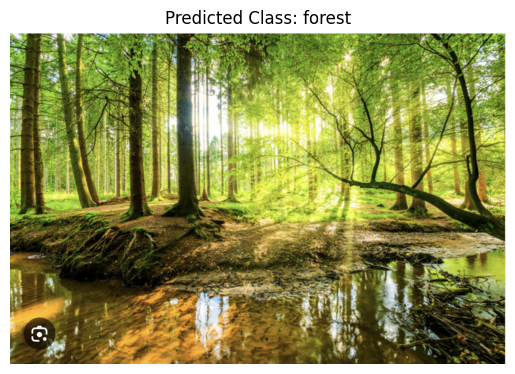

In [ ]:
import matplotlib.pyplot as plt

# Display the image and its predicted class
plt.imshow(image)
plt.title(f"Predicted Class: {predicted_class_name}")
plt.axis('off') # Hide axes ticks and labels
plt.show()

### Confusion Matrix

### Subtask:
Add necessary imports for `matplotlib.pyplot` and `sklearn.metrics` to the notebook for confusion matrix calculation and visualization.


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("Libraries for confusion matrix and plotting imported.")

Libraries for confusion matrix and plotting imported.


**Reasoning**:
Now that the necessary libraries are imported, I will gather all true labels and model predictions from the `test_loader` to prepare for confusion matrix calculation. This involves iterating through the test set in evaluation mode, collecting labels, and corresponding predictions.



In [ ]:
y_true = []
y_pred = []

loaded_model.eval() # Set the model to evaluation mode

with torch.no_grad(): # Disable gradient calculation
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = loaded_model(inputs)
        _, predicted = torch.max(outputs.data, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

print("True labels and predicted labels collected.")

True labels and predicted labels collected.


**Reasoning**:
With the true labels and predicted labels collected, I will now compute the confusion matrix using `sklearn.metrics.confusion_matrix` and then display it using `ConfusionMatrixDisplay` with appropriate labels.



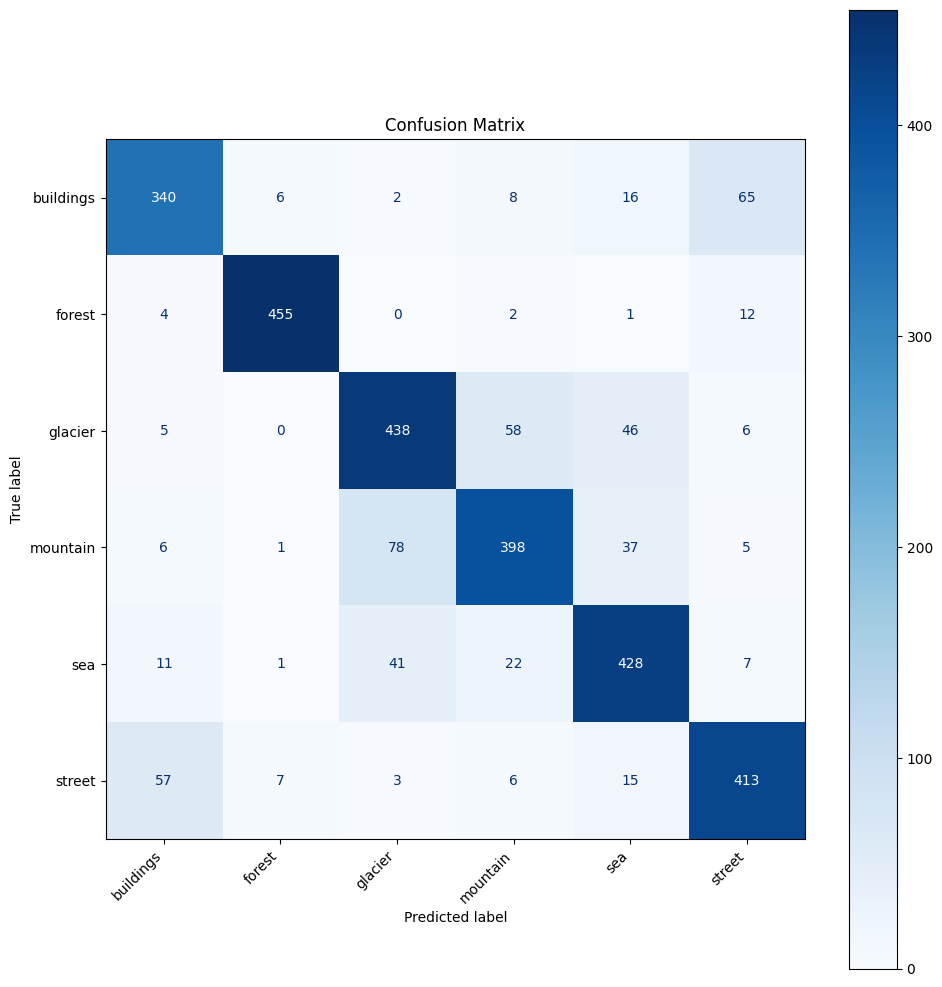

Confusion matrix displayed.


In [ ]:
cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(test_dataset.classes)))
class_names = test_dataset.classes

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(cmap=plt.cm.Blues, ax=ax)
ax.set_title("Confusion Matrix")
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

print("Confusion matrix displayed.")

## Part 5 - Transfer Learning

### Introduce Transfer Learning

### What is Transfer Learning?
Transfer learning is a machine learning technique where a model developed for a task is reused as the starting point for a model on a second task. It's a popular approach in deep learning where pre-trained models (models trained on large, generic datasets) are used as a base, and then fine-tuned for a specific, often smaller, target dataset.

### Benefits of Transfer Learning:
1.  **Faster Training**: Training a deep neural network from scratch requires significant computational resources and time. With transfer learning, you start with an already trained model, drastically reducing the training time.
2.  **Better Performance with Less Data**: Deep learning models typically require vast amounts of data to perform well. Transfer learning allows achieving high performance even with relatively small target datasets because the pre-trained model has already learned a rich set of features from a much larger dataset.
3.  **Overcoming Limited Computational Resources**: Since less training is required, transfer learning is beneficial when you don't have access to high-end GPUs or extensive computing clusters.
4.  **Improved Generalization**: Pre-trained models have learned general features (like edge detectors, texture patterns) that are useful across various image recognition tasks, leading to better generalization on new, unseen data.

### Using Pre-trained Models like ResNet18:
Models like **ResNet18** (Residual Network with 18 layers) are prime examples of architectures often used in transfer learning. These models have been pre-trained on massive datasets like ImageNet, which contains millions of images across a thousand categories. By using a pre-trained ResNet18, we can:
*   **Leverage Learned Features**: The initial layers of ResNet18 have learned to detect fundamental visual features. We can keep these layers frozen or fine-tune them slightly.
*   **Adapt to New Classes**: The final classification layer of the pre-trained model can be replaced with a new layer tailored to the specific number of classes in our target dataset. The rest of the model then acts as a powerful feature extractor.

In essence, transfer learning allows us to stand on the shoulders of giants by utilizing the knowledge embedded in models trained on vast amounts of data, accelerating development and improving performance on new tasks.

### Define Transformations for Pre-trained Model



**Reasoning**:
I will define the `transfer_train_transforms` and `transfer_test_transforms` using `torchvision.transforms.Compose` as specified, including resizing, data augmentation for training, tensor conversion, and ImageNet normalization for both. Then, I will print a confirmation message.



In [ ]:
transfer_train_transforms = transforms.Compose([
    transforms.Resize((224, 224)), # Resize to 224x224 for pre-trained models
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(), # Convert images to PyTorch tensors (scales to [0, 1])
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ImageNet normalization
])

transfer_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)), # Resize to 224x224 for pre-trained models
    transforms.ToTensor(), # Convert images to PyTorch tensors (scales to [0, 1])
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ImageNet normalization
])

print("Transfer learning transformations (train and test) defined.")

Transfer learning transformations (train and test) defined.


### Load Training and Test Data for Transfer Learning



**Reasoning**:
I will create a code cell to load the training and test datasets using `torchvision.datasets.ImageFolder` and create `DataLoader` instances with the new transfer learning transformations. This involves using the previously defined `transfer_train_transforms` and `transfer_test_transforms`, and then printing statistics about the created datasets and loaders.



In [ ]:
import os

# Define the path to your training and test data (reusing paths from previous cells)
train_data_path = '/content/drive/MyDrive/datafiles/cnn-nature/seg_train/'
test_data_path = '/content/drive/MyDrive/datafiles/cnn-nature/seg_test/'

# Create the transfer learning training dataset
transfer_train_dataset = torchvision.datasets.ImageFolder(
    root=train_data_path,
    transform=transfer_train_transforms
)

# Create the transfer learning test dataset
transfer_test_dataset = torchvision.datasets.ImageFolder(
    root=test_data_path,
    transform=transfer_test_transforms
)

# Create DataLoader for the transfer learning training set
transfer_train_loader = DataLoader(
    transfer_train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=os.cpu_count()
)

# Create DataLoader for the transfer learning test set
transfer_test_loader = DataLoader(
    transfer_test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=os.cpu_count()
)

print("Transfer learning datasets and DataLoaders created successfully.")
print(f"\nTransfer Learning Training Data:")
print(f"Number of training samples: {len(transfer_train_dataset)}")
print(f"Number of batches in training loader: {len(transfer_train_loader)}")
print(f"Classes found: {transfer_train_dataset.classes}")

print(f"\nTransfer Learning Test Data:")
print(f"Number of test samples: {len(transfer_test_dataset)}")
print(f"Number of batches in test loader: {len(transfer_test_loader)}")
print(f"Classes found: {transfer_test_dataset.classes}")

Transfer learning datasets and DataLoaders created successfully.

Transfer Learning Training Data:
Number of training samples: 14034
Number of batches in training loader: 439
Classes found: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

Transfer Learning Test Data:
Number of test samples: 3000
Number of batches in test loader: 94
Classes found: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


### Load Pre-trained ResNet18 and Freeze Base Layers



**Reasoning**:
I will import `torchvision.models`, load a pre-trained ResNet18 model, freeze all its parameters except the classification layer, and print a confirmation message.



In [ ]:
import torchvision.models as models

# 1. Load a pre-trained ResNet18 model
transfer_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# 2. Freeze all parameters in the network except for the final classification layer
for param in transfer_model.parameters():
    param.requires_grad = False

print("Pre-trained ResNet18 model loaded and its base layers are frozen.")

Pre-trained ResNet18 model loaded and its base layers are frozen.


**Reasoning**:
With the base layers frozen, the next step in transfer learning is to adapt the pre-trained model's final classification layer to our specific task. I will replace the last fully connected layer of ResNet18 with a new `nn.Linear` layer that matches the number of classes in our dataset (6 classes), ensuring only this new layer is trainable.



In [ ]:
import torch.nn as nn

# Get the number of input features for the classifier layer
num_ftrs = transfer_model.fc.in_features

# Replace the final classification layer with a new one for 6 classes
transfer_model.fc = nn.Linear(num_ftrs, len(transfer_train_dataset.classes))

# Move the modified model to the appropriate device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transfer_model.to(device)

print(f"ResNet18 classifier replaced for {len(transfer_train_dataset.classes)} classes.")
print(f"New classifier: {transfer_model.fc}")

ResNet18 classifier replaced for 6 classes.
New classifier: Linear(in_features=512, out_features=6, bias=True)



I will define the loss function `nn.CrossEntropyLoss()` and the optimizer `optim.Adam()` for the transfer learning model. The optimizer will be configured to only update the parameters of the newly added classification layer (`transfer_model.fc`), as the base layers of ResNet18 are frozen.

### Define Loss and Optimizer for Transfer Learning

### Subtask:
Define the loss function (nn.CrossEntropyLoss) and optimizer (optim.Adam) for the transfer learning model, ensuring the optimizer only updates the parameters of the newly added classification layer.


In [ ]:
import torch.optim as optim

# 1. Define loss function for multi-class classification
transfer_criterion = nn.CrossEntropyLoss()

# 2. Define optimizer, ensuring it only updates the parameters of the new classification layer
transfer_optimizer = optim.Adam(transfer_model.fc.parameters(), lr=0.001)

print("Loss function (CrossEntropyLoss) and optimizer (Adam) defined for transfer learning model, targeting only the classification layer.")

Loss function (CrossEntropyLoss) and optimizer (Adam) defined for transfer learning model, targeting only the classification layer.


### Transfer Learning Training Loop

### Subtask:
Implement the training loop for the transfer learning model, iterating over epochs, batches from the `transfer_train_loader`, performing forward and backward passes, and updating the model's parameters. Include logging of training loss and accuracy per epoch.


In [ ]:
num_epochs = 20 # You can adjust this number

for epoch in range(num_epochs):
    transfer_model.train() # Set the model to training mode
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for i, (inputs, labels) in enumerate(transfer_train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        transfer_optimizer.zero_grad()

        outputs = transfer_model(inputs)
        loss = transfer_criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        transfer_optimizer.step()

        running_loss += loss.item()

        # Calculate training accuracy
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_accuracy = 100 * correct_train / total_train
    # Print statistics after each epoch
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(transfer_train_loader):.4f}, Training Accuracy: {train_accuracy:.2f}%")

print("Transfer learning training complete!")

Epoch 1/20, Loss: 0.5784, Training Accuracy: 81.19%
Epoch 2/20, Loss: 0.3855, Training Accuracy: 86.30%
Epoch 3/20, Loss: 0.3569, Training Accuracy: 86.90%
Epoch 4/20, Loss: 0.3535, Training Accuracy: 87.37%
Epoch 5/20, Loss: 0.3435, Training Accuracy: 87.48%


### Evaluate Transfer Learning Model

### Subtask:
Evaluate the trained transfer learning model on the `transfer_test_loader` to calculate its accuracy on the test set. This involves setting the model to evaluation mode and disabling gradient calculation.


In [ ]:
transfer_model.eval() # Set the loaded_model to evaluation mode
correct_test = 0
total_test = 0

with torch.no_grad(): # Disable gradient calculation for inference
    for inputs, labels in transfer_test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = transfer_model(inputs)

        # For multi-class classification with CrossEntropyLoss,
        # the model outputs logits. We need to find the class with the highest logit.
        _, predicted = torch.max(outputs.data, 1)

        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()

test_accuracy = 100 * correct_test / total_test
print(f"Accuracy on the transfer learning test set: {test_accuracy:.2f}%")


### Save Transfer Learning Model

### Subtask:
Save the trained transfer learning model's state dictionary to Google Drive, similar to how the custom CNN model was saved.


In [ ]:
import os

# Define a path to save your model in Google Drive
transfer_model_save_path = '/content/drive/MyDrive/datafiles/training_parameters/cnn_transferlearn_resnet18_nature_model.pth'

# Save the model's state_dict
torch.save(transfer_model.state_dict(), transfer_model_save_path)

print(f"Transfer learning model parameters saved to: {transfer_model_save_path}")